In [1]:
from lib import *
gatherer = Gatherer()
pd.set_option('display.max_rows', None)
df = gatherer.get_survey_df()
df.head()

,user_id,partner_id,convo_id,date,survey_duration_in_seconds,time_zone,pre_affect,pre_arousal,technical_quality,conv_length,...,my_conscientious,my_neurotic,my_open,your_extraversion,your_agreeable,your_conscientious,your_neurotic,your_open,who_i_talked_to_most_past24,most_common_format_past24
0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,0020a0c5-1658-4747-99c1-2839e736b481,2020-11-10,4115,6.0,5.0,4.0,1.0,45.0,...,4.000000,4.000000,3.666667,4.333333,4.000000,4.666667,3.000000,4.666667,NaN,NaN
1,5fa072f4f4aa580b63834357,5a73899f9cdd1800017786f0,0020a0c5-1658-4747-99c1-2839e736b481,2020-11-10,3949,6.0,7.0,6.0,1.0,43.0,...,2.333333,4.333333,5.000000,4.000000,4.000000,4.333333,2.666667,3.666667,NaN,NaN
2,5f482b0da1cde52de45f174c,5f57120cba207c18f058a62b,002d68da-7738-4177-89d9-d72ae803e0e4,2020-11-15,3293,8.0,7.0,6.0,1.0,34.0,...,2.666667,4.666667,4.333333,4.333333,3.666667,2.666667,4.000000,4.000000,NaN,NaN
3,5f57120cba207c18f058a62b,5f482b0da1cde52de45f174c,002d68da-7738-4177-89d9-d72ae803e0e4,2020-11-15,4393,5.0,7.0,5.0,1.0,34.0,...,2.666667,5.000000,4.666667,3.000000,4.333333,5.000000,1.666667,4.666667,NaN,NaN
4,5d510396f6725b001a4fc025,5dd5bc3bd5cef8000b9861d5,00411458-8275-4b92-a000-d52187f03604,2020-01-09,3215,6.0,6.0,4.0,2.0,35.0,...,2.333333,4.333333,2.000000,5.000000,4.333333,3.666667,2.000000,3.000000,NaN,NaN


In [6]:
df2 = gatherer.get_audio_video_features_df()


AttributeError: 'Gatherer' object has no attribute 'get_audio_video_features_df'

In [5]:
df2.shape

(1656, 10)

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
df['my_isolation_pre_covid'].unique()

array([nan,  2.,  4.,  1.,  3.,  5.,  6.,  7.])

In [22]:
import pandas as pd

# 1. โชว์ทุกคอลัมน์ (ไม่ซ่อนตรงกลาง)
pd.set_option('display.max_columns', None)

# 2. บังคับให้ .info() คำนวณ Null count เสมอ (แม้คอลัมน์จะเยอะก็ไม่ย่อ)
pd.set_option('display.max_info_columns', 500) 

# ลองรันดูอีกทีครับ
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 222 columns):
 #    Column                                 Non-Null Count  Dtype  
---   ------                                 --------------  -----  
 0    user_id                                3312 non-null   object 
 1    partner_id                             3312 non-null   object 
 2    convo_id                               3312 non-null   object 
 3    date                                   3312 non-null   object 
 4    survey_duration_in_seconds             3312 non-null   int64  
 5    time_zone                              3265 non-null   float64
 6    pre_affect                             3312 non-null   float64
 7    pre_arousal                            3312 non-null   float64
 8    technical_quality                      3306 non-null   float64
 9    conv_length                            3306 non-null   float64
 10   affect                                 3257 non-null   flo

In [24]:
# กำหนดตัวแปรเป้าหมาย
target_col = 'my_isolation_pre_covid'

# 1. คำนวณ Correlation ของตัวเลขทั้งหมด
all_corr = df.select_dtypes(include=['number']).corr()[target_col]

# 2. กรองเฉพาะตัวที่เกิน 0.25 (ใช้ abs() เพื่อนับรวมค่าติดลบที่สัมพันธ์กันสูงด้วย)
# และตัดตัวมันเอง (correlation = 1.0) ออก เพื่อไม่ให้เกะกะ
relevant_vars = all_corr[abs(all_corr) > 0.25].drop(target_col, errors='ignore')

# 3. เรียงลำดับจากมากไปน้อย (ตามความแรงของความสัมพันธ์)
relevant_vars_sorted = relevant_vars.reindex(relevant_vars.abs().sort_values(ascending=False).index)

# 4. แสดงผล
print(f"ตัวแปรที่ Relate กับ '{target_col}' เกิน 0.25 มีดังนี้:\n")
if len(relevant_vars_sorted) > 0:
    for col_name, corr_val in relevant_vars_sorted.items():
        print(f"{col_name}: {corr_val:.4f}")
else:
    print("ไม่มีตัวแปรไหนที่มีความสัมพันธ์เกิน 0.25 เลยครับ (อาจต้องใช้ Mean Impute แทน)")

ตัวแปรที่ Relate กับ 'my_isolation_pre_covid' เกิน 0.25 มีดังนี้:

conversation_hours_past24: -1.0000
my_sad_pre_covid: 0.4403
my_stress_pre_covid: 0.4071
my_loneliness: 0.3947
my_isolation_post_covid: 0.3941
my_distracted_pre_covid: 0.3855
my_neurotic: 0.3649
my_bfi_9: 0.3641
i_feel_left_out: 0.3598
my_sad_post_covid: 0.3534
i_feel_isolated: 0.3443
my_distracted_post_covid: 0.3322
my_stress_post_covid: 0.3087
i_lack_companionship: 0.3030
my_bfi_8: 0.3025
my_conscientious: -0.2940
my_extraversion: -0.2749
my_bfi_4: 0.2668
pre_affect: -0.2579
my_bfi_14: -0.2529


In [ ]:
def plot_correlation_matrix( df,select_columns = None , title = 'Correlation Matrix' , figsize = (10,8)):
    if select_columns:
        data_to_use = df[select_columns]
    else:
        data_to_use = df

    corr = data_to_use.corr(numeric_only = True)
    plt.figure(figsize = figsize)
    sns.heatmap(corr , annot = True , cmap = 'coolwarm' , fmt = '.2f' , linewidths = 0.5 , square = True)
    plt.title(title , size = 15)
    plt.show()
    #annot = True คือโชว์ตัวเลขในช่องสี่เหลี่ยม 

In [ ]:
def plot_hist_custom(df , columns ,xlim = None , ylim = None ,figsize = (10,6)) :
    plt.figure(figsize)
    for col in columns :
        plt.figure(figsize)
        sns.histplot(df[col])
        if xlim:
            plt.xlim(xlim)
        if ylim:
            plt.ylim(ylim)
        
        plt.title(f'the distribution of {col}')
        plt.xlabel(f'{col}')
        plt.ylabel(f'Frequency')
#ไม่ใช่ df[col] เพราะว่าเราไม่ได้ต้องการ series เราต้องการแค่ตัว col และ ตัว xlim ylim จะรับเป็น tuple    

In [ ]:
def checking_missing_value(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count/len(df)) * 100

    missing_table = pd.DataFrame({
        'missing_count' : missing_count ,
        'missing_percent' : missing_percent
    })
    #Missing table เป็น DataFrame 
    missing_table = missing_table[missing_table['missing_count'] > 0]
    return missing_table.sort_values(by = 'missing_percent' , ascending = False)

In [ ]:
def clean_duplicate(df):
    former_rows = len(df)
    df_clean = df.drop_duplicates(keep = 'first')
    new_rows = len(df_clean)
    diff = former_rows - new_rows

    print(f'Original Row {former_rows}')
    print(f'Clean Row  {new_rows}')
    print(f'Diff {diff}')

    return df_clean

In [ ]:
def analyze_category(df,columns): #ใช้งานต้องใส่ Column เปน list เท่านั้น
    for col in columns:
        print(col)
        print(df[col].nunique())
        print('*' * 10)
    
        counts = df[col].value_counts(dropna = False)
        percent = (df[col].value_counts(dropna = False ,normalize = True) * 100).round(2)

        summary_table = pd.DataFrame({
        'count' : counts ,
        'percent' : percent
        })

        print(summary_table)
    


In [4]:
# 1. กำหนดตัวแม่แบบ (Reference)
target_col = 'my_isolation_pre_covid'
print(f"Scanning for variables with the exact same missing pattern as '{target_col}'...")
print("-" * 60)

# 2. สร้างลายแทง (Pattern) ของตัวแม่แบบ
ref_pattern = df[target_col].isnull()

# 3. วนลูปเช็คทุกคอลัมน์ใน df
found_vars = []

for col in df.columns:
    # ข้ามตัวมันเองไปก่อน
    if col == target_col:
        continue
        
    # เช็คว่า Pattern การ Null เหมือนกันเป๊ะไหม?
    if df[col].isnull().equals(ref_pattern):
        found_vars.append(col)

# 4. ประกาศผลลัพธ์
if len(found_vars) > 0:
    print(f"Found {len(found_vars)} variables that are missing in the exact same rows as '{target_col}':")
    print("-" * 30)
    for var in found_vars:
        # เช็คว่าเป็นตัวในกลุ่มเดิม หรือตัวใหม่ที่ไม่เคยรู้มาก่อน
        # (ต้องมั่นใจว่าตัวแปร cols_to_check ถูกประกาศไว้ก่อนหน้านี้แล้ว)
        if 'cols_to_check' in locals() and var not in cols_to_check:
            status = "(NEW FOUND!)"
        elif 'cols_to_check' in locals():
            status = "(In original list)"
        else:
            status = ""
            
        print(f"   - {var}  {status}")
else:
    print("No other variables found with the exact same missing pattern.")

print("-" * 60)
print("Insight: Variables marked as '(NEW FOUND!)' are ones you might have missed.")

Scanning for variables with the exact same missing pattern as 'my_isolation_pre_covid'...
------------------------------------------------------------
Found 22 variables that are missing in the exact same rows as 'my_isolation_pre_covid':
------------------------------
   - conversation_count_past24  
   - convo_who_family  
   - convo_who_romantic_partner  
   - convo_who_friends  
   - convo_who_work_colleagues  
   - convo_who_other  
   - convo_format_in_person  
   - convo_format_video_chat  
   - convo_format_phone_call  
   - convo_format_text  
   - convo_format_other  
   - my_isolation_post_covid  
   - my_stress_pre_covid  
   - my_distracted_pre_covid  
   - my_sad_pre_covid  
   - my_stress_post_covid  
   - my_distracted_post_covid  
   - my_sad_post_covid  
   - n_living_with_me_pre_covid  
   - n_living_with_me_post_covid  
   - who_i_talked_to_most_past24  
   - most_common_format_past24  
------------------------------------------------------------
Insight: Variables 

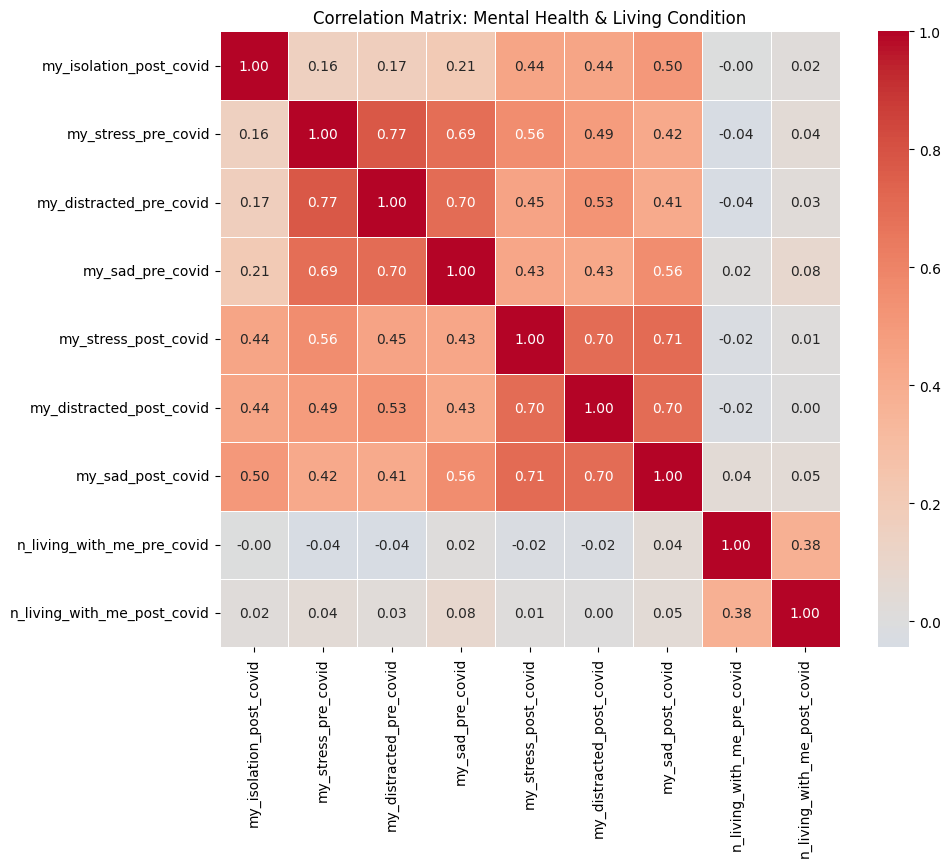

--- Correlation Coefficients ---
                             my_isolation_post_covid  my_stress_pre_covid  \
my_isolation_post_covid                     1.000000             0.158355   
my_stress_pre_covid                         0.158355             1.000000   
my_distracted_pre_covid                     0.165892             0.774678   
my_sad_pre_covid                            0.211009             0.692766   
my_stress_post_covid                        0.438150             0.561452   
my_distracted_post_covid                    0.442258             0.488543   
my_sad_post_covid                           0.502918             0.415003   
n_living_with_me_pre_covid                 -0.004867            -0.044575   
n_living_with_me_post_covid                 0.024715             0.041184   

                             my_distracted_pre_covid  my_sad_pre_covid  \
my_isolation_post_covid                     0.165892          0.211009   
my_stress_pre_covid                         0.77

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. เลือกคอลัมน์ที่ต้องการ
selected_cols = [
    'my_isolation_post_covid',
    'my_stress_pre_covid', 'my_distracted_pre_covid', 'my_sad_pre_covid',
    'my_stress_post_covid', 'my_distracted_post_covid', 'my_sad_post_covid',
    'n_living_with_me_pre_covid', 'n_living_with_me_post_covid'
]

# 2. สร้าง DataFrame เฉพาะกลุ่มนี้ (กรองเฉพาะคอลัมน์ที่มีจริงกัน Error)
existing_cols = [col for col in selected_cols if col in df.columns]
subset_df = df[existing_cols]

# 3. คำนวณ Correlation
corr_matrix = subset_df.corr()

# 4. แสดงผลเป็นกราฟ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,       # โชว์ตัวเลข
    cmap='coolwarm',  # สีแดง=บวก, น้ำเงิน=ลบ
    fmt=".2f",        # ทศนิยม 2 ตำแหน่ง
    linewidths=0.5,
    center=0
)
plt.title("Correlation Matrix: Mental Health & Living Condition")
plt.show()

# 5. (แถม) แสดงเป็นตารางตัวเลขสำหรับ Copy ไปใช้
print("--- Correlation Coefficients ---")
print(corr_matrix)

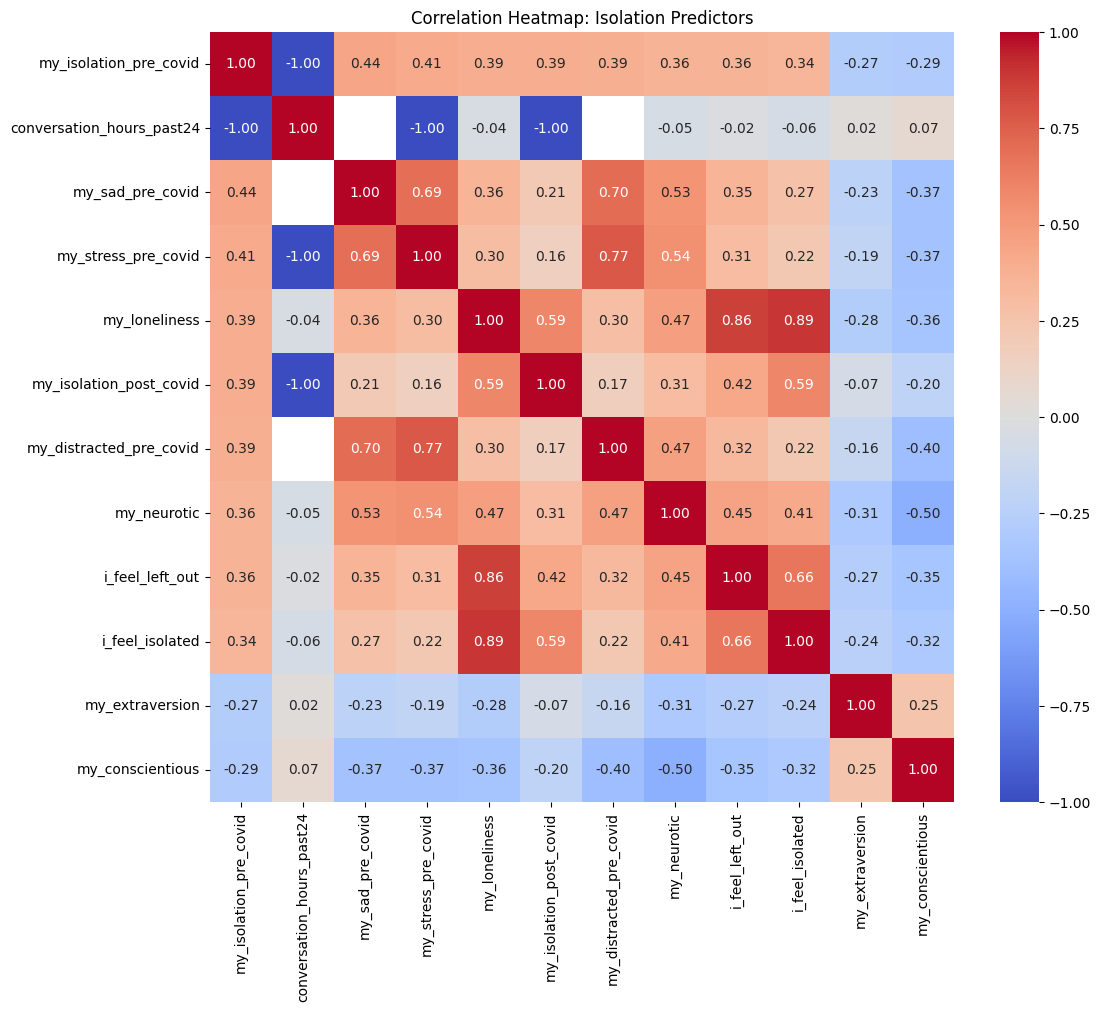

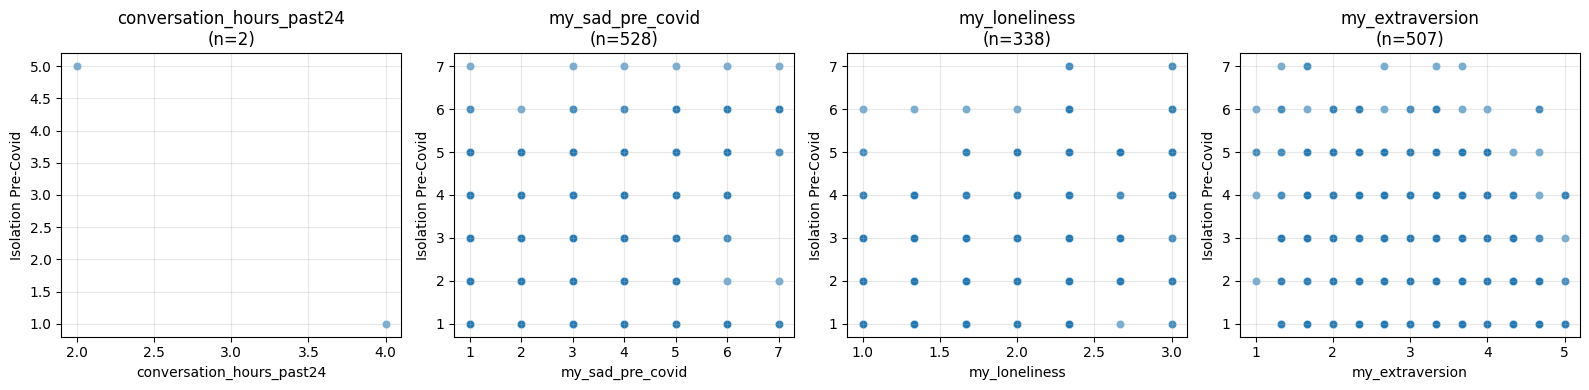

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. รายชื่อตัวแปรที่คุณคัดมา (เรียงตามความแรง)
selected_vars = [
    'my_isolation_pre_covid',      # Target
    'conversation_hours_past24',   # ตัวต้องสงสัย (-1.0)
    'my_sad_pre_covid', 
    'my_stress_pre_covid', 
    'my_loneliness', 
    'my_isolation_post_covid',
    'my_distracted_pre_covid',
    'my_neurotic',
    'i_feel_left_out',
    'i_feel_isolated',
    'my_extraversion',
    'my_conscientious'
]

# กรองเฉพาะที่มีใน df จริง
cols_to_plot = [c for c in selected_vars if c in df.columns]

# --- PART A: Heatmap ดูภาพรวม ---
plt.figure(figsize=(12, 10))
correlation_matrix = df[cols_to_plot].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Heatmap: Isolation Predictors")
plt.show()

# --- PART B: เจาะดู Scatter Plot ของตัวท็อปๆ ---
# เราจะดู 4 ตัวแรกที่สัมพันธ์แรงที่สุด
top_predictors = [
    'conversation_hours_past24', # อยากเห็นหน้าตาตัวนี้
    'my_sad_pre_covid',          # สัมพันธ์บวก
    'my_loneliness',             # สัมพันธ์บวก
    'my_extraversion'            # สัมพันธ์ลบ
]

plt.figure(figsize=(16, 4))
for i, col in enumerate(top_predictors):
    if col in df.columns:
        plt.subplot(1, 4, i+1)
        
        # Plot จุด
        sns.scatterplot(x=df[col], y=df['my_isolation_pre_covid'], alpha=0.6)
        
        # *เช็คจำนวนจุดข้อมูล* (สำคัญสำหรับตัว -1.0)
        valid_data_count = df[[col, 'my_isolation_pre_covid']].dropna().shape[0]
        
        plt.title(f"{col}\n(n={valid_data_count})")
        plt.ylabel("Isolation Pre-Covid")
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# 📋 1. ลิสต์ตัวแปรที่คุณสงสัย (Copy ของคุณมาใส่เลย)
cols_to_check = [
    'my_isolation_pre_covid',
    'my_isolation_post_covid',
    'my_stress_pre_covid',
    'my_distracted_pre_covid',
    'my_sad_pre_covid',
    'my_stress_post_covid',
    'my_distracted_post_covid',
    'my_sad_post_covid',
    'n_living_with_me_pre_covid',
    'n_living_with_me_post_covid'
]

print(f"🕵️‍♂️ กำลังตรวจสอบความสัมพันธ์การหายของ {len(cols_to_check)} ตัวแปร...")
print("-" * 50)

# 2. ใช้ Logic เช็ค (แม่นยำที่สุด)
# วิธีคิด: เอา Pattern การหายของ "ตัวแรก" มาเป็นแม่แบบ แล้วเทียบกับ "ทุกตัวที่เหลือ"
first_col = cols_to_check[0]
reference_pattern = df[first_col].isnull()

# เช็คว่าทุกคอลัมน์ในลิสต์ มีหน้าตาเหมือนแม่แบบเป๊ะไหม?
are_all_same = df[cols_to_check].apply(lambda x: x.isnull().equals(reference_pattern)).all()

# 3. ประกาศผล
if are_all_same:
    print("YES! คอนเฟิร์ม 100%")
    print(f"   ตัวแปรทั้ง {len(cols_to_check)} ตัวนี้ 'หายพร้อมกันเป๊ะ' ในทุกแถวครับ")
    print("   (เป็นแพ็กเกจเดียวกัน ขาดคือขาดครบ มาคือมาครบ)")
else:
    print("NO! ไม่ได้หายพร้อมกันทั้งหมด")
    print("   มีบางตัวที่แถวนี้หาย แต่อีกตัวไม่หาย (ลองเช็คดูใหม่นะ)")
    
    # แถม: ถ้ามันไม่เหมือนกัน อยากรู้ว่าตัวไหนแตกแถว?
    print("\nตัวไหนบ้างที่ Pattern ไม่เหมือนเพื่อน (False = ไม่เหมือน):")
    check_each = df[cols_to_check].apply(lambda x: x.isnull().equals(reference_pattern))
    print(check_each[~check_each]) # ปริ้นท์เฉพาะตัวที่ไม่เหมือน

print("-" * 50)

🕵️‍♂️ กำลังตรวจสอบความสัมพันธ์การหายของ 10 ตัวแปร...
--------------------------------------------------
YES! คอนเฟิร์ม 100%
   ตัวแปรทั้ง 10 ตัวนี้ 'หายพร้อมกันเป๊ะ' ในทุกแถวครับ
   (เป็นแพ็กเกจเดียวกัน ขาดคือขาดครบ มาคือมาครบ)
--------------------------------------------------


In [2]:
#what EDA want 
list_of_eda = ['user_id',
    'politics', 
    'my_isolation_pre_covid',
    'my_isolation_post_covid',
    'my_stress_pre_covid',
    'my_distracted_pre_covid',
    'my_sad_pre_covid',
    'my_stress_post_covid',
    'my_distracted_post_covid',
    'my_sad_post_covid',
    'n_living_with_me_pre_covid',
    'n_living_with_me_post_covid'
]

In [7]:
#explore EDA variable 
only_eda_person  =  df[list_of_eda]
print(only_eda_person.shape)
print(only_eda_person.info())
print(only_eda_person.nunique())
#check which null 
print(only_eda_person.isnull().sum())

(3312, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      3312 non-null   object 
 1   politics                     3256 non-null   float64
 2   my_isolation_pre_covid       528 non-null    float64
 3   my_isolation_post_covid      528 non-null    float64
 4   my_stress_pre_covid          528 non-null    float64
 5   my_distracted_pre_covid      528 non-null    float64
 6   my_sad_pre_covid             528 non-null    float64
 7   my_stress_post_covid         528 non-null    float64
 8   my_distracted_post_covid     528 non-null    float64
 9   my_sad_post_covid            528 non-null    float64
 10  n_living_with_me_pre_covid   528 non-null    float64
 11  n_living_with_me_post_covid  528 non-null    float64
dtypes: float64(11), object(1)
memory usage: 310.6+ KB
None
user_id   

In [3]:
eda_version_1 = df[list_of_eda].copy()
eda_version_2 = df[list_of_eda].copy()


print(id(eda_version_1) == id(eda_version_2))

False


In [4]:
eda_version_1.head()

,user_id,politics,my_isolation_pre_covid,my_isolation_post_covid,my_stress_pre_covid,my_distracted_pre_covid,my_sad_pre_covid,my_stress_post_covid,my_distracted_post_covid,my_sad_post_covid,n_living_with_me_pre_covid,n_living_with_me_post_covid
0,5a73899f9cdd1800017786f0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5fa072f4f4aa580b63834357,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5f482b0da1cde52de45f174c,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5f57120cba207c18f058a62b,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5d510396f6725b001a4fc025,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# 1. คัดเฉพาะแถวที่ user_id ซ้ำ (เอามาทุกแถวเพื่อเทียบกัน)
dup_df = df[df.duplicated(subset=['user_id'], keep=False)].copy()

if dup_df.empty:
    print("ไม่มี user_id ซ้ำในข้อมูลชุดนี้เลยครับ (Clean!)")
else:
    # 2. Group ตาม user_id แล้วนับว่ามีคำตอบกี่แบบในแต่ละคอลัมน์ (nunique)
    # ถ้าตอบเหมือนกันหมด nunique ต้องได้ 1
    # ถ้าตอบต่างกัน nunique จะได้ > 1
    check_consistency = dup_df.groupby('user_id')[['n_living_with_me_pre_covid', 'n_living_with_me_post_covid']].nunique()

    # 3. หาคนที่ตอบ "ไม่เหมือนกัน" (Inconsistent)
    # คือคนที่มีค่า nunique > 1 ในคอลัมน์ใดคอลัมน์หนึ่ง
    inconsistent_users = check_consistency[
        (check_consistency['n_living_with_me_pre_covid'] > 1) | 
        (check_consistency['n_living_with_me_post_covid'] > 1)
    ]

    total_dup_users = len(check_consistency)
    count_inconsistent = len(inconsistent_users)
    count_consistent = total_dup_users - count_inconsistent

    # 4. แสดงผลลัพธ์
    print(f"จาก User ที่มี ID ซ้ำทั้งหมด: {total_dup_users} คน")
    print(f"--------------------------------------------------")
    print(f"✅ ตอบเหมือนเดิมเป๊ะ (Consistent Pattern): {count_consistent} คน ({(count_consistent/total_dup_users)*100:.2f}%)")
    print(f"❌ ตอบเปลี่ยนไป/ไม่เหมือนเดิม (Inconsistent): {count_inconsistent} คน ({(count_inconsistent/total_dup_users)*100:.2f}%)")
    
    if count_inconsistent > 0:
        print("\nตัวอย่าง User ที่ตอบไม่เหมือนเดิม (User ID):")
        print(inconsistent_users.head().index.tolist())
        
        # โชว์ข้อมูลจริงของคนแรกที่ข้อมูลขัดแย้งให้ดู
        sample_bad_id = inconsistent_users.index[0]
        print(f"\nข้อมูลของ User: {sample_bad_id}")
        print(dup_df[dup_df['user_id'] == sample_bad_id][['user_id', 'n_living_with_me_pre_covid', 'n_living_with_me_post_covid']])

จาก User ที่มี ID ซ้ำทั้งหมด: 754 คน
--------------------------------------------------
✅ ตอบเหมือนเดิมเป๊ะ (Consistent Pattern): 738 คน (97.88%)
❌ ตอบเปลี่ยนไป/ไม่เหมือนเดิม (Inconsistent): 16 คน (2.12%)

ตัวอย่าง User ที่ตอบไม่เหมือนเดิม (User ID):
['5b48e77c369f84000112a85c', '5c0017c8f4fb890001d68650', '5c5da579bfe5280001448433', '5d1aadf961a40900171f6931', '5d1e5e30a043ee0019453932']

ข้อมูลของ User: 5b48e77c369f84000112a85c
                       user_id  n_living_with_me_pre_covid  \
1095  5b48e77c369f84000112a85c                         3.0   
1820  5b48e77c369f84000112a85c                         2.0   

      n_living_with_me_post_covid  
1095                          3.0  
1820                          2.0  


In [8]:
eda_version_1['politics'].value_counts()
map_dict = {1 : 'Very Conservative' , 2: 'Conservative' , 3 : 'Centrist/Neutral' , 4: 'Liberal' , 6:'Very Liberal'}
eda_version_1['politics'] = eda_version_1['politics'].replace(map_dict)

In [10]:
eda_version_1['politics'].value_counts(dropna = False)

politics
Liberal              1195
Very Liberal          906
Centrist/Neutral      674
Conservative          395
Very Conservative      86
NaN                    56
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_13620\2563558240.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_13620\2563558240.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Present', 'Missing'])
C:\Users\USER\AppData\Local\Temp\ipykernel_13620\2563558240.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_13620\2563558240.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Pr

✅ บันทึกรูปภาพ 'missing_analysis_plot.png' เรียบร้อยครับ


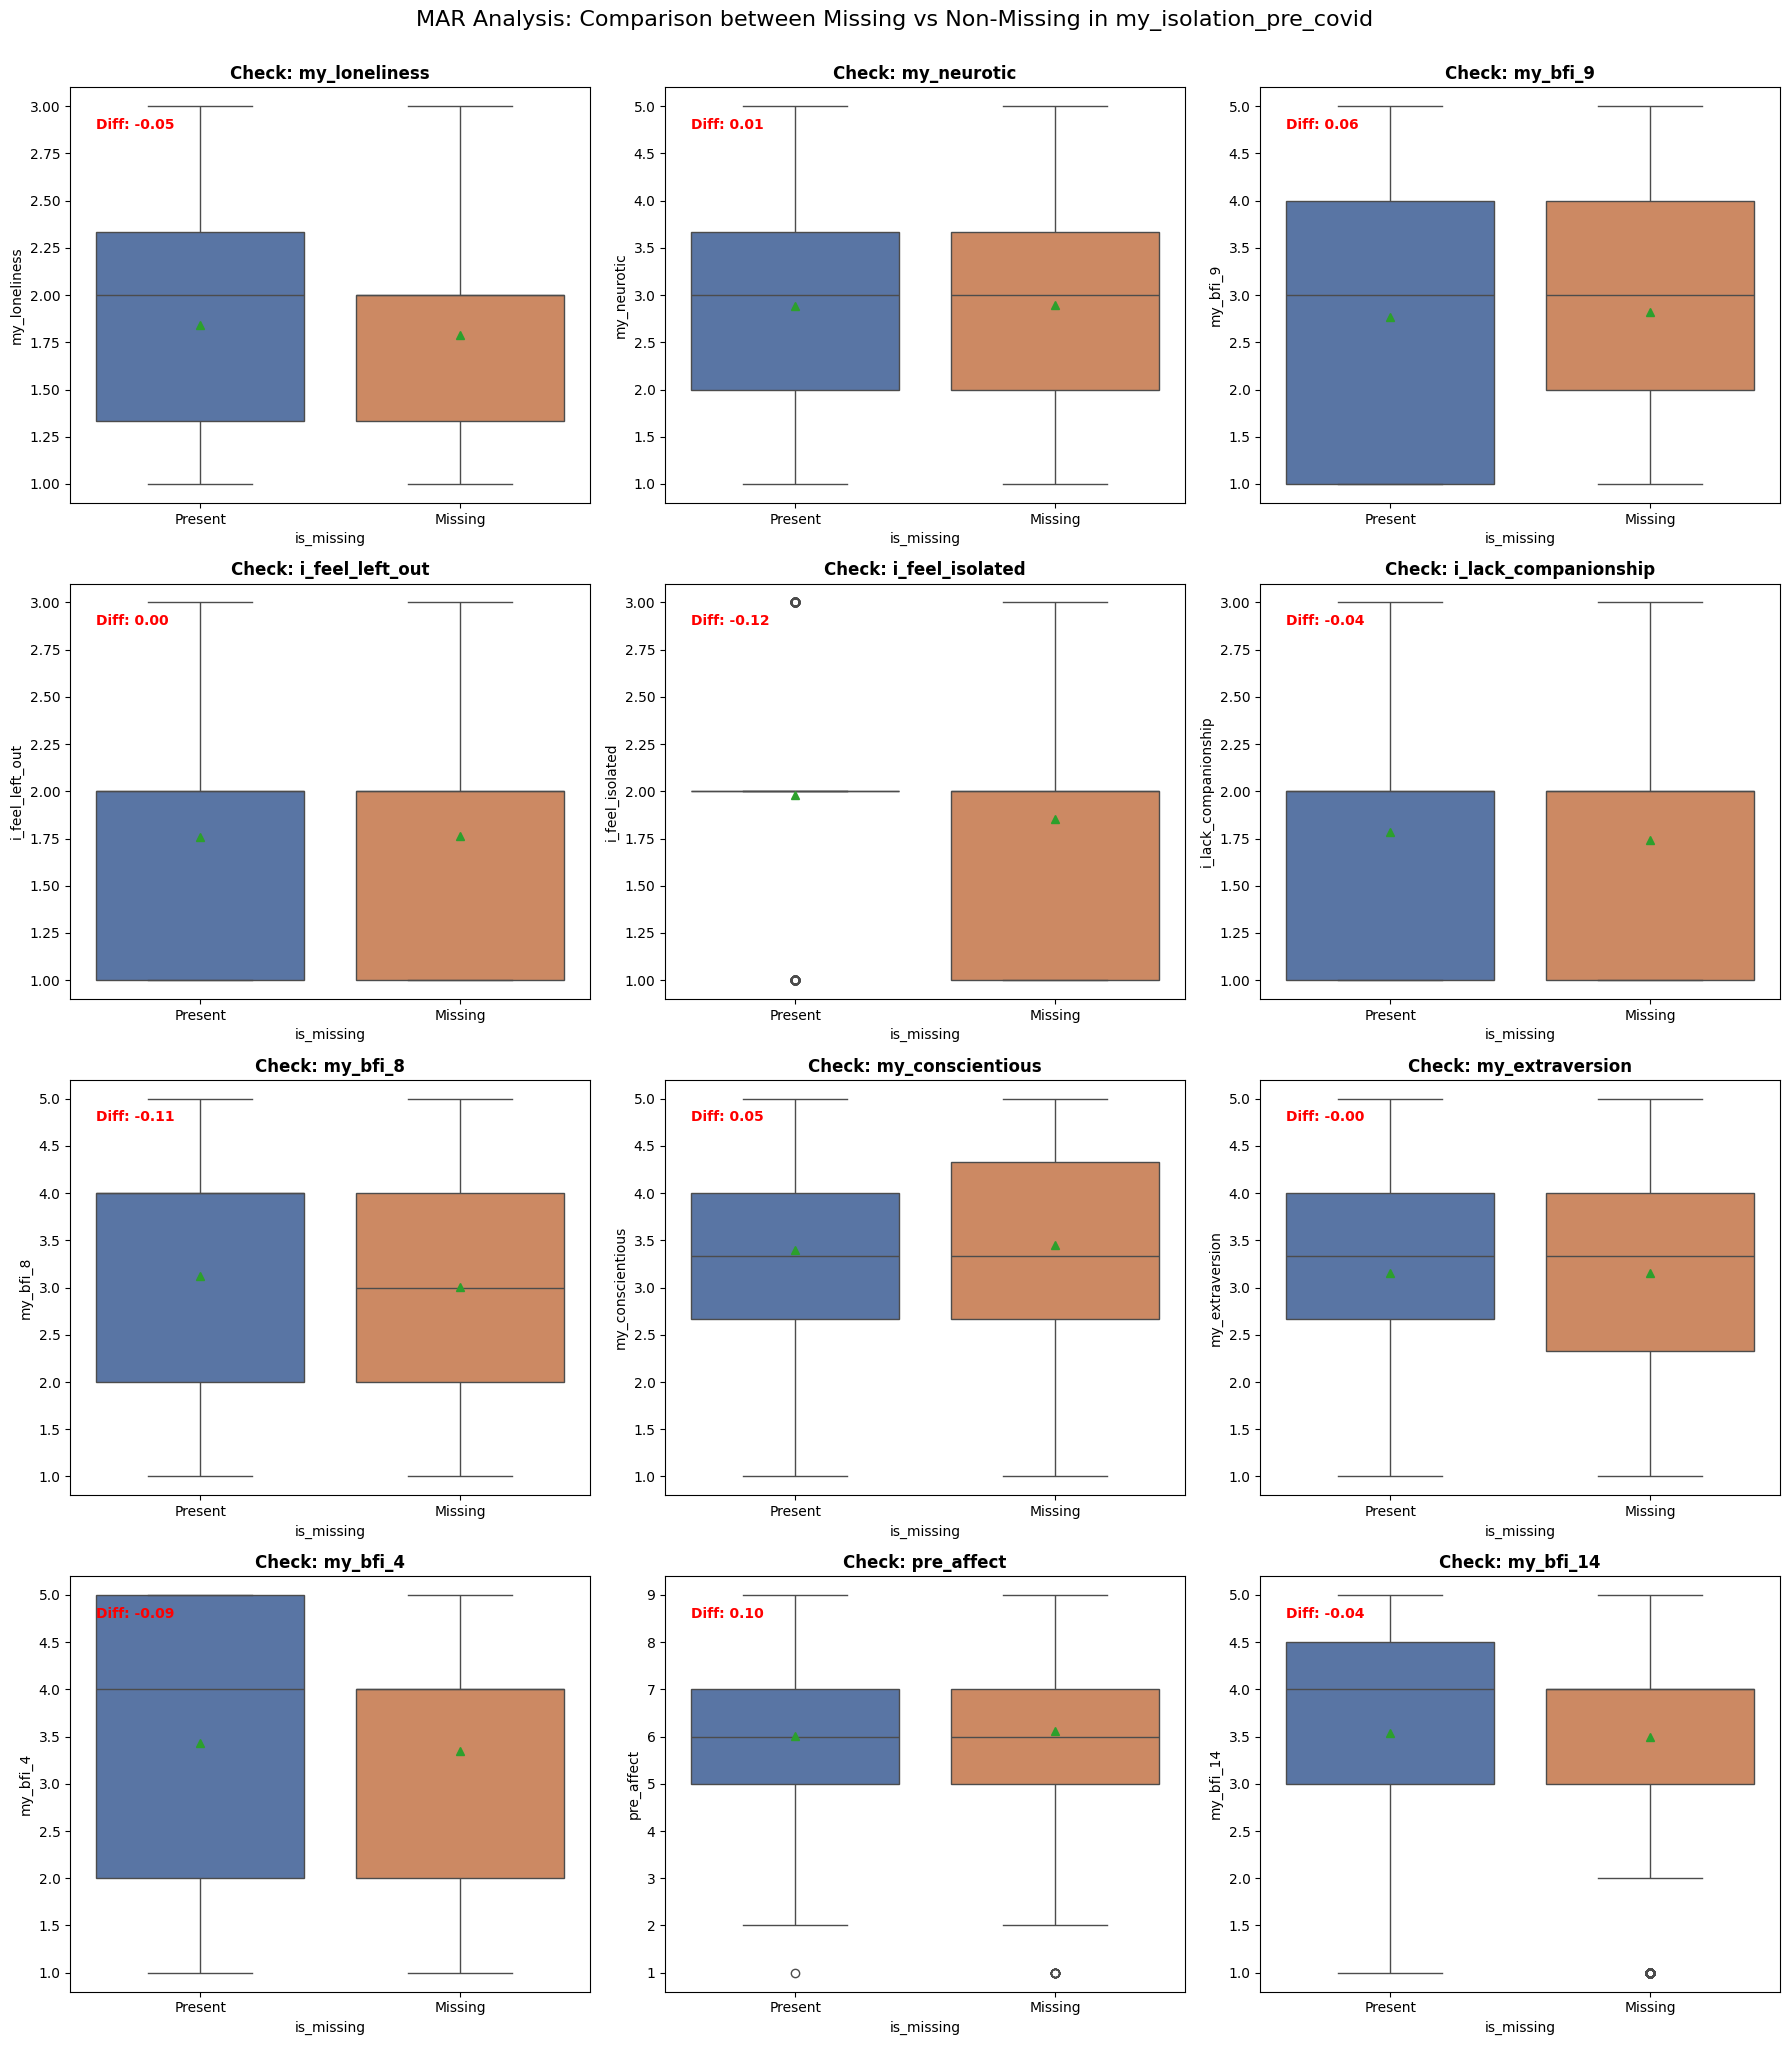


   สรุปความแตกต่าง (Diff) ระหว่างกลุ่ม Missing vs Present
Variable                  | Diff (Missing - Present)  | Interpet
-----------------------------------------------------------------
my_loneliness             | -0.0544                    | Similar (MCAR?)
my_neurotic               |  0.0059                    | Similar (MCAR?)
my_bfi_9                  |  0.0624                    | Similar (MCAR?)
i_feel_left_out           |  0.0034                    | Similar (MCAR?)
i_feel_isolated           | -0.1232                    | Similar (MCAR?)
i_lack_companionship      | -0.0436                    | Similar (MCAR?)
my_bfi_8                  | -0.1138                    | Similar (MCAR?)
my_conscientious          |  0.0550                    | Similar (MCAR?)
my_extraversion           | -0.0044                    | Similar (MCAR?)
my_bfi_4                  | -0.0869                    | Similar (MCAR?)
pre_affect                |  0.1004                    | Similar (MCAR?)
my_bfi_

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# 1. รายชื่อตัวแปร
predictors = [
    'my_loneliness', 'my_neurotic', 'my_bfi_9',
    'i_feel_left_out', 'i_feel_isolated', 'i_lack_companionship',
    'my_bfi_8', 'my_conscientious', 'my_extraversion',
    'my_bfi_4', 'pre_affect', 'my_bfi_14'
]

# 2. เตรียมข้อมูล (แก้เรื่อง Boolean เป็น String เพื่อกัน Error)
target_col = 'my_isolation_pre_covid'
df_plot = df.copy() # หรือ eda_version_1.copy()
df_plot['is_missing'] = df_plot[target_col].isnull().astype(str)

# 3. ตั้งค่าหน้ากระดาษ
n_cols = 3
n_rows = math.ceil(len(predictors) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# เก็บผลลัพธ์ไว้รายงาน
stats_report = []

# 4. วนลูปวาดกราฟ
for i, col in enumerate(predictors):
    if col in df_plot.columns:
        sns.boxplot(
            x='is_missing', y=col, data=df_plot, ax=axes[i],
            palette={'False': "#4c72b0", 'True': "#dd8452"}, 
            showmeans=True, order=['False', 'True']
        )
        
        axes[i].set_title(f"Check: {col}", fontsize=12, fontweight='bold')
        axes[i].set_xticklabels(['Present', 'Missing'])
        
        # คำนวณค่าทางสถิติเพื่อเอามาดู
        try:
            mean_present = df_plot[df_plot['is_missing'] == 'False'][col].mean()
            mean_missing = df_plot[df_plot['is_missing'] == 'True'][col].mean()
            diff = mean_missing - mean_present
            
            # เก็บค่าไว้โชว์
            stats_report.append({
                'Variable': col,
                'Mean_Present': mean_present,
                'Mean_Missing': mean_missing,
                'Diff': diff
            })
            
            # เขียนลงในกราฟ
            axes[i].text(0.05, 0.9, f"Diff: {diff:.2f}", transform=axes[i].transAxes, color='red', fontweight='bold')
        except:
            pass

# 5. ลบกราฟเกิน
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle(f'MAR Analysis: Comparison between Missing vs Non-Missing in {target_col}', y=1.02, fontsize=16)

# --- SAVE รูปภาพ ---
plt.savefig('missing_analysis_plot.png', bbox_inches='tight', dpi=100)
print("✅ บันทึกรูปภาพ 'missing_analysis_plot.png' เรียบร้อยครับ")

plt.show()

# --- PRINT ผลลัพธ์ให้คุณก๊อปมาให้ผมดู ---
print("\n" + "="*50)
print("   สรุปความแตกต่าง (Diff) ระหว่างกลุ่ม Missing vs Present")
print("="*50)
print(f"{'Variable':<25} | {'Diff (Missing - Present)':<25} | {'Interpet'}")
print("-" * 65)

for item in stats_report:
    diff = item['Diff']
    # ช่วยแปลผลเบื้องต้น
    interp = "Different! (MAR)" if abs(diff) > 0.3 else "Similar (MCAR?)"
    print(f"{item['Variable']:<25} | {diff: .4f} {' '*18} | {interp}")

In [6]:
# 1. สร้างลิสต์รายชื่อคอลัมน์ที่ต้องการเติม 0
cols_to_impute = [
    'my_isolation_pre_covid', 'my_isolation_post_covid',
    'my_stress_pre_covid',    'my_distracted_pre_covid',
    'my_sad_pre_covid',       'my_stress_post_covid',
    'my_distracted_post_covid','my_sad_post_covid'
]

# 2. ทำการแทนค่า Null ด้วย 0 (ใช้กับ DataFrame ที่คุณต้องการ เช่น eda_version_1 หรือ df หลัก)
# แนะนำให้ทำกับ eda_version_1 ก่อนเพื่อทดสอบ
eda_version_1[cols_to_impute] = eda_version_1[cols_to_impute].fillna(0)

# 3. เช็คผลลัพธ์ว่าเหลือ Null ไหม
print(eda_version_1[cols_to_impute].isnull().sum())

my_isolation_pre_covid      0
my_isolation_post_covid     0
my_stress_pre_covid         0
my_distracted_pre_covid     0
my_sad_pre_covid            0
my_stress_post_covid        0
my_distracted_post_covid    0
my_sad_post_covid           0
dtype: int64


In [11]:
# ลบเฉพาะแถวที่ column 'politics' เป็นค่าว่าง
eda_version_1 = eda_version_1.dropna(subset=['politics'])

# เช็คจำนวนแถวที่เหลือ
print(f"จำนวนแถวที่เหลือ: {len(eda_version_1)}")

จำนวนแถวที่เหลือ: 3256


In [12]:
eda_version_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3256 entries, 0 to 3311
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      3256 non-null   object 
 1   politics                     3256 non-null   object 
 2   my_isolation_pre_covid       3256 non-null   float64
 3   my_isolation_post_covid      3256 non-null   float64
 4   my_stress_pre_covid          3256 non-null   float64
 5   my_distracted_pre_covid      3256 non-null   float64
 6   my_sad_pre_covid             3256 non-null   float64
 7   my_stress_post_covid         3256 non-null   float64
 8   my_distracted_post_covid     3256 non-null   float64
 9   my_sad_post_covid            3256 non-null   float64
 10  n_living_with_me_pre_covid   3256 non-null   float64
 11  n_living_with_me_post_covid  3256 non-null   float64
dtypes: float64(10), object(2)
memory usage: 330.7+ KB


In [13]:
# 1. หาจำนวนค่า politics ที่ไม่ซ้ำกันของแต่ละ user_id
# ถ้าตอบเหมือนกันตลอด ค่าต้องเป็น 1
# ถ้ามีเปลี่ยนขั้ว ค่าจะเป็น > 1
politics_consistency = eda_version_1.groupby('user_id')['politics'].nunique()

# 2. กรองหาคนที่ "เปลี่ยนขั้ว" (unique > 1)
changed_users = politics_consistency[politics_consistency > 1]
changed_user_ids = changed_users.index.tolist()

# 3. แสดงผลลัพธ์
print(f"พบ User ที่เปลี่ยนขั้ว/ตอบการเมืองไม่เหมือนเดิมทั้งหมด: {len(changed_user_ids)} คน")

if len(changed_user_ids) > 0:
    print("\n--- ตัวอย่าง User ที่เปลี่ยนขั้ว (10 คนแรก) ---")
    print(changed_user_ids[:10])

    print("\n--- รายละเอียดข้อมูล (เรียงตาม User ID) ---")
    # ดึงข้อมูลจริงมาโชว์ให้เห็นเลยว่าเปลี่ยนจากอะไรเป็นอะไร
    display_cols = ['user_id', 'politics'] 
    
    # ถ้ามี column วันที่ (date) หรือเวลา ให้เพิ่มเข้าไปด้วยจะเห็นลำดับการเปลี่ยนชัดขึ้น
    if 'date' in eda_version_1.columns:
        display_cols.append('date')
        
    example_data = eda_version_1[eda_version_1['user_id'].isin(changed_user_ids)][display_cols].sort_values(by='user_id')
    print(example_data.head(20))
else:
    print("\nผลลัพธ์: ไม่พบ User ที่เปลี่ยนขั้วทางการเมืองเลยครับ (ทุกคนจุดยืนมั่นคง!)")

พบ User ที่เปลี่ยนขั้ว/ตอบการเมืองไม่เหมือนเดิมทั้งหมด: 107 คน

--- ตัวอย่าง User ที่เปลี่ยนขั้ว (10 คนแรก) ---
['55c4ea6dfdf99b4adb996618', '56db4c217dcddf000bd5853c', '571cea664ca277001153c045', '57272517e386b9000e3e2b72', '597b858909bdcf000153ff58', '59d5c894c732930001d88b5e', '5a198755f2e3460001edc5c9', '5a791168f49c9a0001f31061', '5b48e77c369f84000112a85c', '5b66ce776f0d0400010d678d']

--- รายละเอียดข้อมูล (เรียงตาม User ID) ---
                       user_id          politics
2898  55c4ea6dfdf99b4adb996618  Centrist/Neutral
1174  55c4ea6dfdf99b4adb996618      Conservative
1266  55c4ea6dfdf99b4adb996618      Conservative
1464  56db4c217dcddf000bd5853c      Very Liberal
2470  56db4c217dcddf000bd5853c      Very Liberal
3234  56db4c217dcddf000bd5853c      Very Liberal
3056  56db4c217dcddf000bd5853c           Liberal
2448  571cea664ca277001153c045           Liberal
1883  571cea664ca277001153c045           Liberal
572   571cea664ca277001153c045           Liberal
1778  571cea664ca277001

In [1]:
# 1. นับจำนวนแถวที่ซ้ำ
num_duplicates = eda_version_1.duplicated().sum()

# 2. คำนวณเป็นเปอร์เซ็นต์ (เผื่ออยากดูสัดส่วน)
pct_duplicates = (num_duplicates / len(eda_version_1)) * 100

print(f"มีข้อมูลซ้ำทั้งหมด: {num_duplicates} แถว")
print(f"คิดเป็น: {pct_duplicates:.2f}% ของข้อมูลทั้งหมด")

NameError: name 'eda_version_1' is not defined

In [12]:
# 1. หาจำนวนแถวที่ user_id ซ้ำทั้งหมด (ไม่ว่าจะซ้ำแบบเหมือนหรือต่าง)
# keep=False คือเอาขึ้นมาโชว์ทุกแถวที่ user_id ซ้ำ
all_id_dups = eda_version_1[eda_version_1.duplicated(subset=['user_id'], keep=False)]
count_all_id_dups = len(all_id_dups)

# 2. ในกลุ่มที่ ID ซ้ำนั้น... มีกี่แถวที่ "ซ้ำกันทุกคอลัมน์" (Exact Duplicate)
exact_dups = all_id_dups[all_id_dups.duplicated(keep=False)]
count_exact_dups = len(exact_dups)

# 3. ที่เหลือคือ "ID ซ้ำ แต่ข้อมูลข้างในต่างกัน" (Conflict)
count_conflict = count_all_id_dups - count_exact_dups

# --- คำนวณเปอร์เซ็นต์ ---

if count_all_id_dups == 0:
    print("ไม่มี user_id ซ้ำเลยครับ (Clean!)")
else:
    # เทียบกับ ID Duplicate ทั้งหมด
    pct_exact = (count_exact_dups / count_all_id_dups) * 100
    pct_conflict = (count_conflict / count_all_id_dups) * 100

    print(f"จากข้อมูลที่มี user_id ซ้ำทั้งหมด: {count_all_id_dups} แถว")
    print(f"--------------------------------------------------")
    print(f"1. ซ้ำแบบเหมือนกันเป๊ะ (Exact Dups): {count_exact_dups} แถว ({pct_exact:.2f}%)")
    print(f"   => (แนวทาง: ลบทิ้งให้เหลือแถวเดียวได้เลย)")
    print(f"\n2. ซ้ำแต่ข้อมูลต่างกัน (Conflict):   {count_conflict} แถว ({pct_conflict:.2f}%)")
    print(f"   => (แนวทาง: ต้องเช็คเวลา หรือเลือกค่าล่าสุด)")

จากข้อมูลที่มี user_id ซ้ำทั้งหมด: 2610 แถว
--------------------------------------------------
1. ซ้ำแบบเหมือนกันเป๊ะ (Exact Dups): 2131 แถว (81.65%)
   => (แนวทาง: ลบทิ้งให้เหลือแถวเดียวได้เลย)

2. ซ้ำแต่ข้อมูลต่างกัน (Conflict):   479 แถว (18.35%)
   => (แนวทาง: ต้องเช็คเวลา หรือเลือกค่าล่าสุด)


ผลการตรวจสอบ: ตัวแปรทั้ง 10 ตัว Null พร้อมกันเสมอหรือไม่?
YES! มันหายไปพร้อมกันเป๊ะๆ ทุกแถว (Perfect Match)
   แปลว่า: ถ้าตัวนึงหาย ตัวอื่นในกลุ่มนี้ก็จะหายไปด้วยทั้งหมด


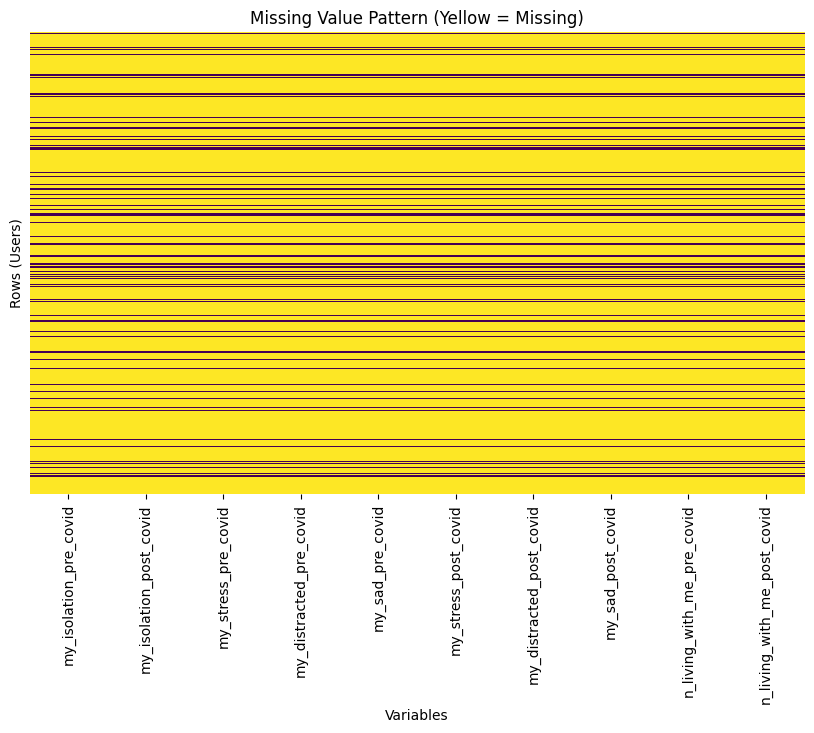

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_check = [
    'my_isolation_pre_covid',
    'my_isolation_post_covid',
    'my_stress_pre_covid',
    'my_distracted_pre_covid',
    'my_sad_pre_covid',
    'my_stress_post_covid',
    'my_distracted_post_covid',
    'my_sad_post_covid',
    'n_living_with_me_pre_covid',
    'n_living_with_me_post_covid'
]

# 2. สร้างตาราง Check Null (True=Null, False=มีค่า)
null_pattern = df[cols_to_check].isnull()

# --- วิธีพิสูจน์ที่ 1: เช็คด้วย Logic (แม่นยำ 100%) ---
# เทียบทุกคอลัมน์กับคอลัมน์แรก ว่าแพทเทิร์นการ Null เหมือนกันเป๊ะไหม?
all_identical = null_pattern.eq(null_pattern.iloc[:, 0], axis=0).all().all()

print(f"ผลการตรวจสอบ: ตัวแปรทั้ง {len(cols_to_check)} ตัว Null พร้อมกันเสมอหรือไม่?")
if all_identical:
    print("YES! มันหายไปพร้อมกันเป๊ะๆ ทุกแถว (Perfect Match)")
    print("   แปลว่า: ถ้าตัวนึงหาย ตัวอื่นในกลุ่มนี้ก็จะหายไปด้วยทั้งหมด")
else:
    print("NO! มีบางแถวที่บางตัวหาย แต่บางตัวอยู่")
    
    # ถ้าไม่เหมือนกัน อยากรู้ว่าต่างกันกี่แถว
    # นับจำนวนแถวที่ "หายไม่พร้อมกัน"
    # (คือในแถวเดียวกัน มีทั้ง True และ False ปนกัน)
    mixed_rows = null_pattern.apply(lambda x: x.nunique() > 1, axis=1).sum()
    print(f"   จำนวนแถวที่หายไม่พร้อมกัน: {mixed_rows} แถว")

# --- วิธีพิสูจน์ที่ 2: ดูด้วยตา (Heatmap) ---
plt.figure(figsize=(10, 6))
sns.heatmap(null_pattern, cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Pattern (Yellow = Missing)')
plt.xlabel('Variables')
plt.ylabel('Rows (Users)')
plt.show()

In [7]:
# 1. ระบุคอลัมน์ที่ต้องการเติม 0 (รวม n_living และตัวอื่นๆ ที่คุยกันไว้)
cols_to_impute_zeros = [
    'n_living_with_me_pre_covid',
    'n_living_with_me_post_covid',
    # ถ้าตัวพวกนี้ยังไม่ได้เติม ก็รวมไปด้วยเลยครับ
    'my_isolation_pre_covid', 'my_isolation_post_covid',
    'my_stress_pre_covid', 'my_stress_post_covid',
    'my_distracted_pre_covid', 'my_distracted_post_covid',
    'my_sad_pre_covid', 'my_sad_post_covid'
]

# 2. กรองเฉพาะคอลัมน์ที่มีอยู่ใน eda_version_1 จริงๆ (กัน Error)
existing_cols = [c for c in cols_to_impute_zeros if c in eda_version_1.columns]

# 3. เติม Null ด้วย 0
eda_version_1[existing_cols] = eda_version_1[existing_cols].fillna(0)

# 4. เช็คผลลัพธ์ (ต้องได้ 0)
print("จำนวน Null ที่เหลือหลังจากเติม 0:")
print(eda_version_1[existing_cols].isnull().sum())

จำนวน Null ที่เหลือหลังจากเติม 0:
n_living_with_me_pre_covid     0
n_living_with_me_post_covid    0
my_isolation_pre_covid         0
my_isolation_post_covid        0
my_stress_pre_covid            0
my_stress_post_covid           0
my_distracted_pre_covid        0
my_distracted_post_covid       0
my_sad_pre_covid               0
my_sad_post_covid              0
dtype: int64


In [18]:
# 1. หาว่า Column ไหนเป็นตัวเลขบ้าง (ที่จะเอาไปหา Mean)
# ไม่รวม user_id เพราะเป็นตัว Group
numeric_cols = eda_version_1.select_dtypes(include=['number']).columns.tolist()

# 2. สร้างคำสั่ง (Dictionary) ว่าแต่ละ Column ให้ทำอะไร
agg_dict = {col: 'mean' for col in numeric_cols} # สั่งให้ตัวเลขทุกตัวหาค่าเฉลี่ย
agg_dict['politics'] = 'last'                    # สั่งให้การเมืองเอาค่าล่าสุด

# 3. เริ่ม Group รวมร่าง
eda_grouped_mixed = eda_version_1.groupby('user_id').agg(agg_dict).reset_index()

# 4. เช็คผลลัพธ์
print(f"จำนวน User ก่อนรวม: {len(eda_version_1)}")
print(f"จำนวน User หลังรวม (Unique): {len(eda_grouped_mixed)}")
print("-" * 30)
print(eda_grouped_mixed.head())

จำนวน User ก่อนรวม: 3256
จำนวน User หลังรวม (Unique): 1431
------------------------------
                    user_id  my_isolation_pre_covid  my_isolation_post_covid  \
0  53979923fdf99b1ccc3f11f6                     0.0                      0.0   
1  555527dafdf99b16a75afd54                     2.0                      5.0   
2  558823c2fdf99b318cb4224b                     0.0                      0.0   
3  558a0bc6fdf99b2d7699a94c                     0.0                      0.0   
4  558a327cfdf99b2d75651681                     0.0                      0.0   

   my_stress_pre_covid  my_distracted_pre_covid  my_sad_pre_covid  \
0                  0.0                      0.0               0.0   
1                  4.0                      4.0               3.0   
2                  0.0                      0.0               0.0   
3                  0.0                      0.0               0.0   
4                  0.0                      0.0               0.0   

   my_stress_p

In [21]:
eda_grouped_mixed.to_csv('survey_groupby.csv', index=False, encoding='utf-8-sig')

In [19]:
import numpy as np

# 1. กำหนดเงื่อนไข (Conditions)
conditions = [
    eda_grouped_mixed['n_living_with_me_pre_covid'] < eda_grouped_mixed['n_living_with_me_post_covid'],
    eda_grouped_mixed['n_living_with_me_pre_covid'] == eda_grouped_mixed['n_living_with_me_post_covid'],
    eda_grouped_mixed['n_living_with_me_pre_covid'] > eda_grouped_mixed['n_living_with_me_post_covid']
]

# 2. กำหนดค่าที่จะใส่ลงไป (Choices) ให้ตรงลำดับกับเงื่อนไข
choices = ['less', 'equal', 'more']

# 3. สร้าง Column ใหม่
eda_grouped_mixed['living_comparison'] = np.select(conditions, choices, default='unknown')

# 4. เช็คผลลัพธ์
print(eda_grouped_mixed[['n_living_with_me_pre_covid', 'n_living_with_me_post_covid', 'living_comparison']].head(10))

# ดูสัดส่วนว่ากลุ่มไหนเยอะสุด
print("\nสัดส่วนกลุ่มต่างๆ:")
print(eda_grouped_mixed['living_comparison'].value_counts())

   n_living_with_me_pre_covid  n_living_with_me_post_covid living_comparison
0                         0.0                          0.0             equal
1                         1.0                          1.0             equal
2                         0.0                          0.0             equal
3                         0.0                          0.0             equal
4                         0.0                          0.0             equal
5                         0.0                          0.0             equal
6                         0.0                          0.0             equal
7                         0.0                          0.0             equal
8                         0.0                          0.0             equal
9                         0.0                          0.0             equal

สัดส่วนกลุ่มต่างๆ:
living_comparison
equal    1343
less       58
more       30
Name: count, dtype: int64


In [22]:
eda_grouped_mixed.shape

(1431, 13)